# 7. Monte Carlo savings projections

**Question:** what range of outcomes can a savings plan expect, and how much can be withdrawn
safely afterwards?

The example plan saves 500 EUR per month (indexed to inflation) for 30 years, then withdraws
4 % of the starting wealth per year (indexed to inflation) for 30 years. Fund costs are
0.20 % per year. Results are in today's money.

Three return models are compared:

* **GBM:** independent lognormal monthly returns calibrated to history.
* **Student-t:** same mean and variance of log returns as GBM, fat-tailed shocks.
* **Block bootstrap:** historical months resampled in blocks (mean length 12) jointly with
  inflation, which keeps autocorrelation, volatility clusters and the link between returns and
  inflation.

German taxation (flat tax, partial exemption, saver's allowance, annual Vorabpauschale, FIFO on
sales) is modelled for a taxable account. See `investor_toolkit.tax` for the rules and
simplifications.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from investor_toolkit.plotting import apply_style

warnings.filterwarnings("ignore", category=FutureWarning)
apply_style()
pd.set_option("display.precision", 3)
pd.set_option("display.width", 120)
FIGURES = "../docs/figures"

from investor_toolkit import montecarlo as mc
from investor_toolkit import proxies
from investor_toolkit.plotting import plot_fan, plot_lines
from investor_toolkit.tax import EQUITY_FUND, MIXED_FUND, GermanTax

In [2]:
long = proxies.long_history()
allocations = {
    "defensive (25/75)": (0.25 * long["world_equity"] + 0.75 * long["bund_10y"], 0.0),
    "balanced (60/40)": (0.60 * long["world_equity"] + 0.40 * long["bund_10y"], MIXED_FUND),
    "growth (100/0)": (long["world_equity"], EQUITY_FUND),
}
history, exemption = allocations["balanced (60/40)"]
plan = mc.SavingsPlan(
    monthly_contribution=500,
    accumulation_years=30,
    withdrawal_years=30,
    withdrawal_rate=0.04,
    annual_fee=0.002,
    tax=GermanTax(partial_exemption=exemption),
)
gbm = mc.GBM.from_returns(history, inflation=long["inflation"].mean() * 12)
models = {
    "GBM": gbm,
    "Student-t (df 5)": mc.StudentT(gbm.expected_return, gbm.volatility, gbm.inflation, df=5.0),
    "Block bootstrap": mc.Bootstrap(history, long["inflation"], mean_block=12),
}
print(
    f"Calibration: expected return {gbm.expected_return:.2%}, volatility {gbm.volatility:.2%}, "
    f"inflation {gbm.inflation:.2%}"
)
results = {name: mc.simulate(model, plan, n_paths=10_000, seed=1) for name, model in models.items()}
pd.DataFrame({name: r.summary() for name, r in results.items()})

Calibration: expected return 6.48%, volatility 8.69%, inflation 2.18%


,GBM,Student-t (df 5),Block bootstrap
invested_real,180000.000,180000.000,180000.000
retirement_median,318106.270,316421.322,319974.979
retirement_p5,195805.249,195168.320,178695.206
retirement_p95,534817.218,532105.849,568715.687
terminal_median,84585.769,86687.238,90351.263
terminal_after_tax_median,71946.447,73721.222,77031.979
taxes_paid_real_mean,95492.071,95680.080,97731.701
success_rate,0.699,0.708,0.680


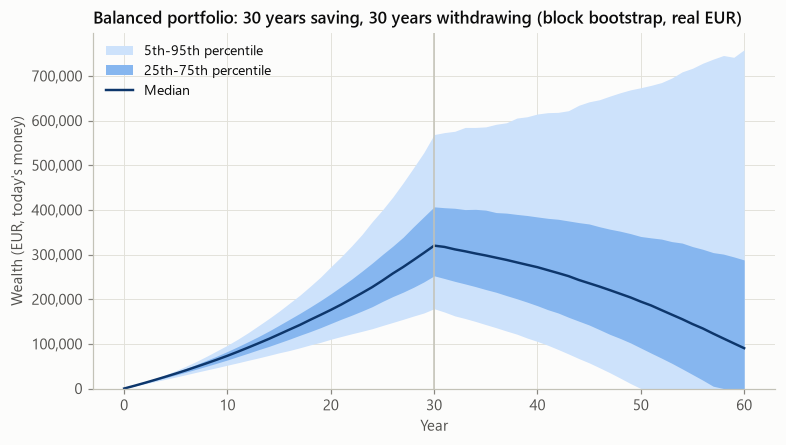

In [3]:
boot = results["Block bootstrap"]
ax = plot_fan(
    boot.percentiles(),
    title="Balanced portfolio: 30 years saving, 30 years withdrawing (block bootstrap, real EUR)",
    ylabel="Wealth (EUR, today's money)",
)
ax.axvline(30, color="#c3c2b7", linewidth=1.0)
ax.figure.savefig(f"{FIGURES}/savings_fan.png")

GBM and Student-t give almost identical results: over decades, monthly fat tails average out.
The bootstrap gives a wider range and a lower success rate. It differs from the parametric models
in what it keeps, not in its tails: runs of bad months and periods of high inflation with weak real
returns. Sequence risk early in the withdrawal phase is what makes plans fail.

## The cost of taxes

In [4]:
rows = {}
for name, (series, exemption) in allocations.items():
    model = mc.Bootstrap(series, long["inflation"], mean_block=12)
    for label, tax in [("tax-free", None), ("taxable", GermanTax(partial_exemption=exemption))]:
        p = mc.SavingsPlan(
            monthly_contribution=500, accumulation_years=30, annual_fee=0.002, tax=tax
        )
        s = mc.simulate(model, p, n_paths=10_000, seed=1).summary()
        rows[(name, label)] = {
            "invested": s["invested_real"],
            "median before liquidation": s["retirement_median"],
            "median after liquidation tax": s["terminal_after_tax_median"],
            "5th percentile": s["retirement_p5"],
            "taxes paid during saving (mean)": s["taxes_paid_real_mean"],
        }
pd.DataFrame(rows).T

invested  median before liquidation  median after liquidation tax  5th percentile  \
defensive (25/75) tax-free  180000.0                 240214.935                    240214.935      157456.922   
                  taxable   180000.0                 231893.226                    213770.486      153547.768   
balanced (60/40)  tax-free  180000.0                 330065.062                    330065.062      179199.238   
                  taxable   180000.0                 319722.536                    286635.206      175693.726   
growth (100/0)    tax-free  180000.0                 467962.528                    467962.528      165148.129   
                  taxable   180000.0                 456186.476                    405330.214      163243.148   

                            taxes paid during saving (mean)  
defensive (25/75) tax-free                            0.000  
                  taxable                          7691.672  
balanced (60/40)  tax-free                            0.000  
                  taxable                          8951.958  
growth (100/0)    tax-free                            0.000  
                  taxable                         10534.318

The annual Vorabpauschale is small while saving; most of the tax falls due when the fund is sold.
Equity funds benefit from the 30 % partial exemption, bond funds from none, so the tax drag
differs by allocation.

## How much can be withdrawn safely?

The safe withdrawal rate is the highest initial withdrawal (as a share of starting wealth,
then indexed to inflation) that does not run out of money in at least 95 % of scenarios. Shown
for a tax-free account with 0.20 % costs, from bootstrapped history.

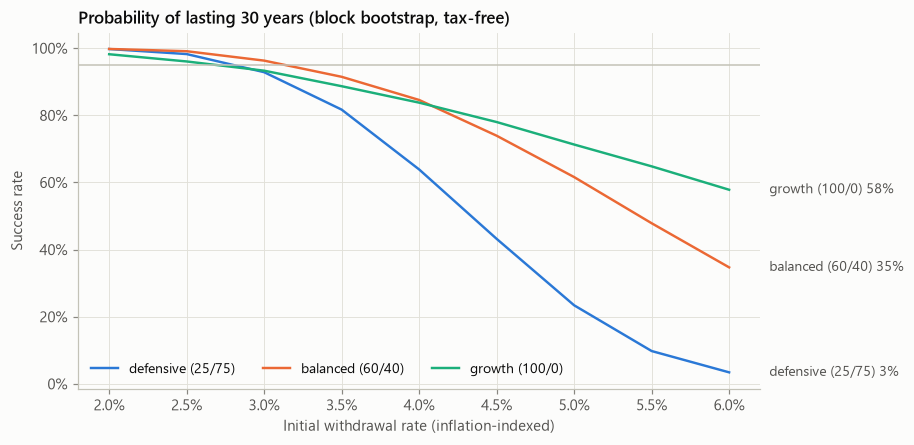

In [5]:
rates = np.round(np.arange(0.02, 0.061, 0.005), 3)
curves = {}
for name, (series, _) in allocations.items():
    model = mc.Bootstrap(series, long["inflation"], mean_block=12)
    curves[name] = [
        mc.simulate(
            model,
            mc.SavingsPlan(
                initial=100_000,
                monthly_contribution=0,
                accumulation_years=0,
                withdrawal_years=30,
                withdrawal_rate=rate,
                annual_fee=0.002,
            ),
            n_paths=4000,
            seed=2,
        ).success_rate()
        for rate in rates
    ]
success = pd.DataFrame(curves, index=rates)
ax = plot_lines(
    success,
    title="Probability of lasting 30 years (block bootstrap, tax-free)",
    percent=True,
    label_fmt=lambda v: f"{v:.0%}",
    legend_loc="lower left",
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1%}"))
ax.set_xlabel("Initial withdrawal rate (inflation-indexed)")
ax.set_ylabel("Success rate")
ax.axhline(0.95, color="#c3c2b7", linewidth=1.0)
ax.figure.savefig(f"{FIGURES}/withdrawal_success.png")

In [6]:
swr = {}
for name, (series, _) in allocations.items():
    model = mc.Bootstrap(series, long["inflation"], mean_block=12)
    for years in (20, 30, 40):
        p = mc.SavingsPlan(
            initial=100_000,
            monthly_contribution=0,
            accumulation_years=0,
            withdrawal_years=years,
            annual_fee=0.002,
        )
        swr[(name, years)] = mc.safe_withdrawal_rate(model, p, target_success=0.95, n_paths=2000)
(pd.Series(swr).unstack() * 100).round(2).rename_axis(
    index="safe withdrawal rate (%)", columns="years"
)

years,20,30,40
safe withdrawal rate (%),,,
balanced (60/40),4.47,3.15,2.57
defensive (25/75),4.24,2.83,2.20
growth (100/0),3.85,2.72,2.18


Measured on EUR returns since 1999 (a period with two deep bear markets and low bond yields for
most of it), the widely quoted 4 % rule falls short of 95 % confidence over 30 years for every
allocation. Longer horizons require lower rates. Results depend on the historical sample, which
contains fewer than three independent 10-year periods; they are a stress-tested planning range,
not a prediction.

**Takeaways**

* The spread of outcomes after 30 years is wide: the 95th percentile is several times the 5th.
* Over long horizons, fat monthly tails matter less than sequences of returns and inflation.
* Taxes reduce final wealth materially, mostly at liquidation.
* A withdrawal rate around 3 % was robust in this history; 4 % was not.